## Setup

In [134]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_seq_items", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 120)


## Load datasets

In [135]:
DATA_DIR = "../data"

train_df = pd.read_csv(f"{DATA_DIR}/train.csv")
val_df   = pd.read_csv(f"{DATA_DIR}/validation.csv")
test_df  = pd.read_csv(f"{DATA_DIR}/test.csv")

splits = {"train": train_df, "validation": val_df, "test": test_df}


## 1. Data Shape

In [136]:
for df_name, df in splits.items():
    print(f"{df_name}: {df.shape[0]} rows, {df.shape[1]} columns")
    print(f"  missing text:  {df['text'].isna().sum()}")
    print(f"  missing label: {df['label'].isna().sum()}")


train: 2270 rows, 116 columns
  missing text:  0
  missing label: 0
validation: 568 rows, 116 columns
  missing text:  0
  missing label: 0
test: 715 rows, 116 columns
  missing text:  0
  missing label: 0


## 2. Keep selected columns

In [137]:
# exclude Lexical features (prefix lex_) columns
# only keep: id, subreddit, text, label

columns = ['id', 'subreddit', 'text', 'label']
splits = {name: df[columns].copy() for name, df in splits.items()}

## 3. Check duplicates

In [138]:

for name, df in splits.items():
    n_dup = df.duplicated(subset=['id']).sum()
    print(f"{name}: {n_dup} duplicate rows (same id)")
    if n_dup:
        display(df[df.duplicated(subset=['id'], keep=False)].sort_values(['id']))


train: 0 duplicate rows (same id)
validation: 0 duplicate rows (same id)
test: 0 duplicate rows (same id)


## 4. Cross-split leakage check

**Question:** does the same post ever appear in more than one split?

In [139]:
train_ids = set(splits["train"]["id"])
val_ids   = set(splits["validation"]["id"])
test_ids  = set(splits["test"]["id"])

print("train & validation overlap?:", len(train_ids & val_ids))
print("train & test overlap?      :", len(train_ids & test_ids))
print("validation & test overlap? :", len(val_ids & test_ids))


train & validation overlap?: 0
train & test overlap?      : 0
validation & test overlap? : 0


## 5. Label Balance

**Question:** Is the target balance?

In [140]:
for name, df in splits.items():
    print(f"\n{name}: n={len(df)}")
    print(df["label"].value_counts(normalize=True).sort_index().round(3))


train: n=2270
label
0    0.481
1    0.519
Name: proportion, dtype: float64

validation: n=568
label
0    0.454
1    0.546
Name: proportion, dtype: float64

test: n=715
label
0    0.484
1    0.516
Name: proportion, dtype: float64


## 6. Text length by label

**Question:** do stress and not-stress posts differ in length? If so, a model could partly learn "length" as a proxy instead of content.


In [141]:
df_train = splits["train"].copy()
df_train["word_count"] = df_train["text"].str.split().str.len()

df_train.groupby("label")["word_count"].describe()[["mean", "50%", "std"]]

,mean,50%,std
label,,,
0,82.642857,78.0,29.481071
1,88.968591,83.0,35.368768


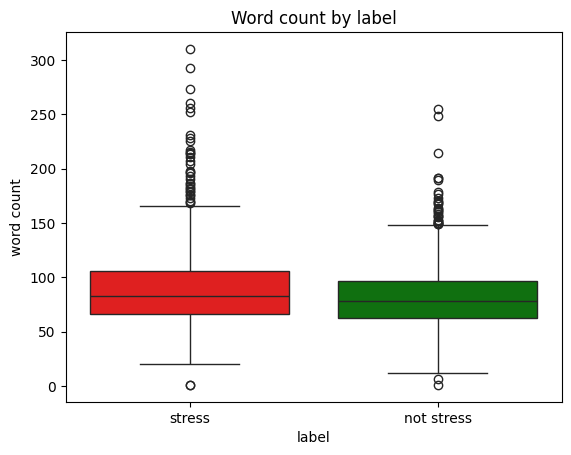

In [142]:
import seaborn as sns

df_train["label_name"] = df_train["label"].map({0: "not stress", 1: "stress"})

sns.boxplot(
    data=df_train,
    x="label_name",
    y="word_count",
    hue="label_name",
    palette={"not stress": "green", "stress": "red"},
    legend=False,
)

plt.title("Word count by label")
plt.xlabel("label")
plt.ylabel("word count")
plt.show()

## 7. The document-frequency distribution

In [143]:
from sklearn.feature_extraction.text import CountVectorizer
import numpy as np

token_pattern=r"\b[a-zA-Z]+(?:'[a-zA-Z]+)?\b" # matches contractions as one token such as "don't" and "I've"

# binary=True: each column is 0/1. If a word is present in a document, 
# it is 1, otherwise 0.
vectorizer = CountVectorizer(binary=True, stop_words="english", token_pattern=token_pattern)
doc_term_matrix = vectorizer.fit_transform(splits["train"]["text"])
vocab = vectorizer.get_feature_names_out()

doc_freq = np.asarray(doc_term_matrix.sum(axis=0)).ravel()
doc_freq_df = pd.DataFrame({"term": vocab, "doc_freq": doc_freq})
doc_freq_df = doc_freq_df.sort_values("doc_freq", ascending=False).reset_index(drop=True)

print(f"Vocabulary size: {len(doc_freq_df)}")
print(f"Training posts: {len(splits['train'])}")

doc_freq_df.head(15)

Vocabulary size: 10031
Training posts: 2270


,term,doc_freq
0,just,727
1,like,680
2,i'm,610
3,know,535
4,time,503
5,feel,437
6,really,429
7,don't,426
8,want,359
9,help,346


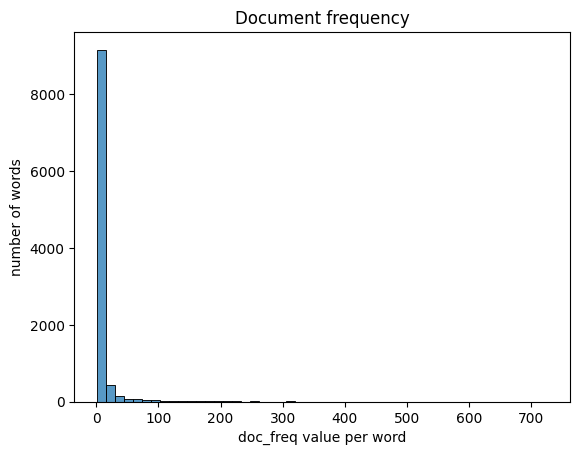

In [144]:
import seaborn as sns

ax = sns.histplot(data=doc_freq_df, x="doc_freq", bins=50)
ax.set_title("Document frequency")
ax.set_xlabel("doc_freq value per word")
ax.set_ylabel("number of words")
plt.show()

In [145]:
vocab_size = len(doc_freq_df)

for n in [1, 2, 5, 10, 20, 50]:
    count = (doc_freq_df["doc_freq"] <= n).sum()
    pct = count / vocab_size * 100
    print(f"{count:>5} ({pct:5.1f}% of vocabulary) words appearing in <= {n:>2} posts")

 4937 ( 49.2% of vocabulary) words appearing in <=  1 posts
 6358 ( 63.4% of vocabulary) words appearing in <=  2 posts
 7985 ( 79.6% of vocabulary) words appearing in <=  5 posts
 8812 ( 87.8% of vocabulary) words appearing in <= 10 posts
 9361 ( 93.3% of vocabulary) words appearing in <= 20 posts
 9768 ( 97.4% of vocabulary) words appearing in <= 50 posts


## Summary of findings

**Note on `id` vs. `post_id`:** `post_id` identifies which Reddit thread a row belongs to (multiple rows can share a thread) and is not unique. `id` is the actual unique row-level key and is what's used for identifiying duplicates and leakage checks.

### 1. Label balance

Proportions are consistent and close to even across all three splits. No class imbalance concern:

| split | label 0 (not stress) | label 1 (stress) |
|---|---|---|
| train | 0.481 | 0.519 |
| validation | 0.454 | 0.546 |
| test | 0.484 | 0.516 |

### 2. Text length by label

Word count computed via whitespace split (`text.str.split().str.len()`).

- Both classes have similar median word count (~78-83 words) and similar IQR (~60-100 words).
- Stress-labeled posts (`label=1`) run slightly longer on average, with a longer upper tail (max ~310 words vs. ~255 for not-stress).


### 3. Document frequency distribution

- Nearly half the vocabulary (49.2%) appears in exactly one training post.
- The distribution is heavily right-skewed. Most of the vocabulary is uncommon, and a small number of common words (`just`, `like`, `i'm`, `know`, `time`, `feel`, `really`, `don't`, ...) dominate document frequency.

| threshold | word count | % of vocabulary |
|---|---|---|
| ≤ 1 post | 4,937 | 49.2% |
| ≤ 2 posts | 6,358 | 63.4% |
| ≤ 5 posts | 7,985 | 79.6% |
| ≤ 10 posts | 8,812 | 87.8% |
| ≤ 20 posts | 9,361 | 93.3% |
| ≤ 50 posts | 9,768 | 97.4% |
